In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_squared_error, r2_score

from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from scipy.stats import kstest
from statsmodels.stats.diagnostic import het_white
# Загрузка датасета Калифорнийского жилья
housing = fetch_california_housing()
# Преобразование в DataFrame для удобства работы
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target

#В качестве целевой переменной для предсказания был выбран признак MedHouseVal (медианная стоимость дома).
print("Первые 5 строк данных:")
df.head()

Первые 5 строк данных:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
print("Количество пропущенных значений:")
print(df.isnull().sum())

Количество пропущенных значений:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


In [4]:
print("Типы данных в столбцах:")
df.info()

Типы данных в столбцах:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


Все признаки в наборе данных являются числовыми, поэтому кодирование не требуется

In [ ]:
# Разделение данных на признаки и целевую переменную
X = df.drop('MedHouseVal', axis=1) 

y = df['MedHouseVal']
# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=66)
# Масштабирование признаков
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print(f"Размер обучающей выборки X: {X_train_scaled.shape}")
print(f"Размер тестовой выборки X: {X_test_scaled.shape}")

Размер обучающей выборки X: (16512, 8)
Размер тестовой выборки X: (4128, 8)


In [6]:
# Обучение моделей линейной регрессии
lr_model = LinearRegression()
# Обычная линейная регрессия
lr_model.fit(X_train_scaled, y_train)
print("1. Обычная линейная регрессия обучена.")

# Ridge регрессия с подбором гиперпараметра alpha
ridge_model = Ridge()

params_ridge = {'alpha': np.logspace(-3, 3, 7)} 

ridge_search = GridSearchCV(ridge_model, params_ridge, cv=5, scoring='r2')

ridge_search.fit(X_train_scaled, y_train)

best_ridge_model = ridge_search.best_estimator_
print(f"2. Ridge регрессия обучена. Лучший параметр alpha: {ridge_search.best_params_['alpha']}")

# Lasso регрессия с подбором гиперпараметра alpha
lasso_model = Lasso(max_iter=10000)

params_lasso = {'alpha': np.logspace(-4, 0, 5)}

lasso_search = GridSearchCV(lasso_model, params_lasso, cv=5, scoring='r2')
lasso_search.fit(X_train_scaled, y_train)

best_lasso_model = lasso_search.best_estimator_
print(f"3. Lasso регрессия обучена. Лучший параметр alpha: {lasso_search.best_params_['alpha']}")

1. Обычная линейная регрессия обучена.
2. Ridge регрессия обучена. Лучший параметр alpha: 100.0
3. Lasso регрессия обучена. Лучший параметр alpha: 0.01


In [7]:
# Анализ значимости признаков с помощью statsmodels
X_train_sm = sm.add_constant(X_train_scaled)

# Создаем и обучаем модель OLS
model_sm = sm.OLS(y_train, X_train_sm).fit()

# Выводим сводную таблицу с результатами
print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:            MedHouseVal   R-squared:                       0.601
Model:                            OLS   Adj. R-squared:                  0.601
Method:                 Least Squares   F-statistic:                     3113.
Date:                Sun, 30 Nov 2025   Prob (F-statistic):               0.00
Time:                        18:45:59   Log-Likelihood:                -18100.
No. Observations:               16512   AIC:                         3.622e+04
Df Residuals:                   16503   BIC:                         3.629e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.0643      0.006    366.209      0.0

Для анализа статистической значимости коэффициентов была построена модель OLS с помощью библиотеки statsmodels. Анализ p-value (столбец P>|t| в сводной таблице) показал, что все признаки имеют p-value < 0.05. Следовательно, все признаки являются статистически значимыми на уровне значимости 5%.

Сравнение коэффициентов моделей:
      Feature  LinearReg     Ridge     Lasso  Lasso_abs
6    Latitude  -0.891352 -0.821634 -0.788091   0.788091
0      MedInc   0.819684  0.814941  0.765670   0.765670
7   Longitude  -0.865658 -0.795087 -0.755234   0.755234
3   AveBedrms   0.316328  0.292751  0.168171   0.168171
1    HouseAge   0.119625  0.127099  0.126471   0.126471
2    AveRooms  -0.274138 -0.255071 -0.126378   0.126378
5    AveOccup  -0.042522 -0.043659 -0.035062   0.035062
4  Population  -0.005347 -0.002601 -0.000000   0.000000


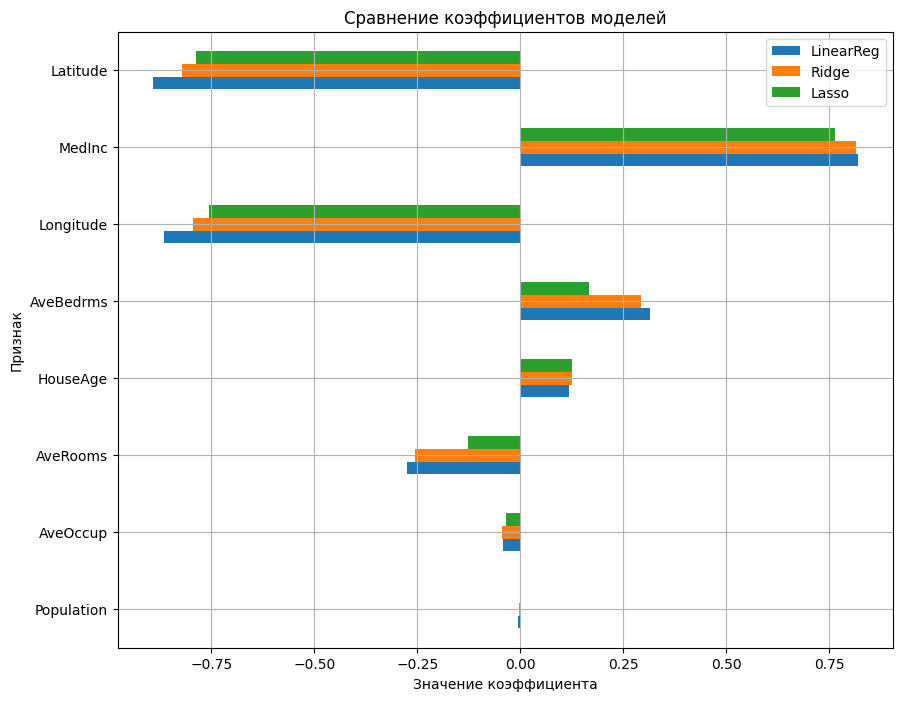

In [8]:
# Сравнение коэффициентов моделей
coeffs = pd.DataFrame(data={
    'Feature': X.columns,
    'LinearReg': lr_model.coef_,
    'Ridge': best_ridge_model.coef_,
    'Lasso': best_lasso_model.coef_
})

# Добавляем столбец с абсолютными значениями коэффициентов Lasso для сортировки
coeffs['Lasso_abs'] = abs(coeffs['Lasso'])

print("Сравнение коэффициентов моделей:")

print(coeffs.sort_values(by='Lasso_abs', ascending=False))

# Визуализация коэффициентов моделей
coeffs.sort_values(by='Lasso_abs').plot(x='Feature', y=['LinearReg', 'Ridge', 'Lasso'], kind='barh', figsize=(10, 8))
plt.title('Сравнение коэффициентов моделей')
plt.xlabel('Значение коэффициента')
plt.ylabel('Признак')
plt.grid(True)
plt.show()

На основе анализа коэффициентов всех трех моделей, самым важным признаком является Latitude (широта). Чем севернее расположен дом в Калифорнии (чем больше широта), тем он дешевле.

In [9]:
# Оценка моделей на тестовой выборке
models = {
    'Linear Regression': lr_model, 
    'Ridge': best_ridge_model, 
    'Lasso': best_lasso_model
}

print("Оценка качества моделей на тестовой выборке:\n")


for name, model in models.items():
    
    predictions = model.predict(X_test_scaled)
    # R² (коэффициент детерминации): показывает, какую долю дисперсии целевой переменной объясняет модель. 
    # Чем ближе к 1, тем лучше.
    r2 = r2_score(y_test, predictions)
    # MSE (Mean Squared Error): средний квадрат ошибки. Сильно штрафует за большие ошибки.
    # Чем меньше, тем лучше.
    mse = mean_squared_error(y_test, predictions)
    
    print(f"--- Модель: {name} ---")
    print(f"  R² (коэффициент детерминации): {r2:.4f}")
    print(f"  MSE (среднеквадратичная ошибка): {mse:.4f}\n")

Оценка качества моделей на тестовой выборке:

--- Модель: Linear Regression ---
  R² (коэффициент детерминации): 0.6161
  MSE (среднеквадратичная ошибка): 0.5351

--- Модель: Ridge ---
  R² (коэффициент детерминации): 0.6146
  MSE (среднеквадратичная ошибка): 0.5373

--- Модель: Lasso ---
  R² (коэффициент детерминации): 0.6156
  MSE (среднеквадратичная ошибка): 0.5358



Для оценки качества моделей на тестовой выборке использовались метрики R² и MSE. Все три модели показали схожие результаты. Лучший результат по метрике R² показала модель Linear Regression (R² = 0.6161) и по метрике MSE = 0.5351.

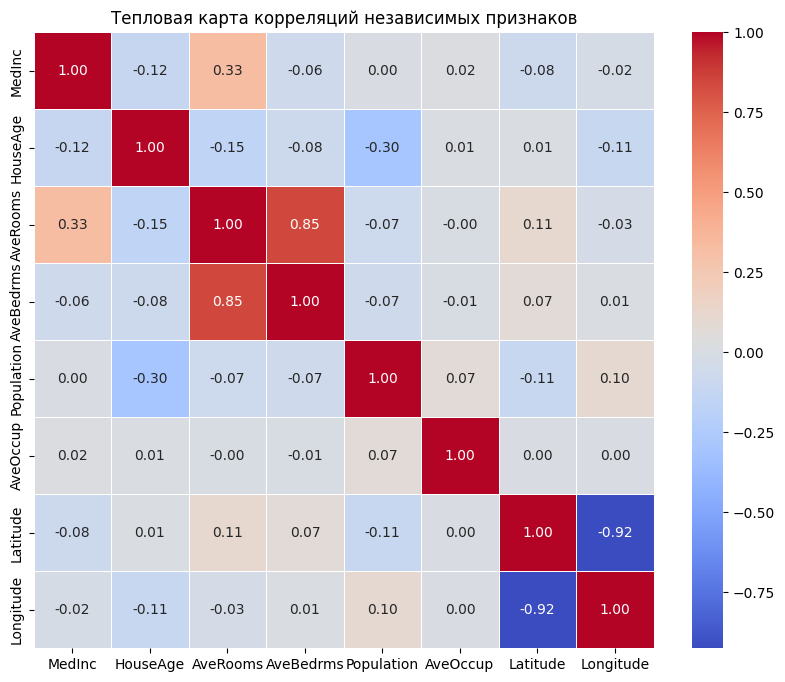


Коэффициенты VIF:
      feature         VIF
7   Longitude  633.711654
6    Latitude  559.874071
2    AveRooms   45.993601
3   AveBedrms   43.590314
0      MedInc   11.511140
1    HouseAge    7.195917
4  Population    2.935745
5    AveOccup    1.095243


In [ ]:
# Анализ мультиколлинеарности
plt.figure(figsize=(10, 8))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Тепловая карта корреляций независимых признаков')
plt.show()

# Создаем пустой DataFrame, куда будем записывать результаты
vif_data = pd.DataFrame()

vif_data["feature"] = X.columns

vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print("\nКоэффициенты VIF:")
print(vif_data.sort_values(by='VIF', ascending=False))

Матрица корреляций выявила две сильные парные связи: между AveRooms и AveBedrms (+0.85) и между Latitude и Longitude (-0.92), что является логичным.
Расчет VIF показал наличие серьезной проблемы мультиколлинеарности. Значения VIF для признаков Latitude (560), Longitude (634), AveRooms (46) и AveBedrms (44) значительно превышают критический порог (VIF > 10).
Наличие высокой мультиколлинеарности означает, что некоторые независимые признаки сильно связаны не только попарно, но и в комбинации друг с другом. Это делает коэффициенты регрессионной модели нестабильными и затрудняет их интерпретацию как меру "важности" каждого отдельного признака. Хотя это не обязательно снижает общую предсказательную точность модели, для построения более интерпретируемой модели в будущем следовало бы, например, удалить один из сильно коррелирующих признаков (например, AveBedrms или Longitude) или объединить их в один новый признак.

--- 7.1 Анализ нормальности распределения остатков ---


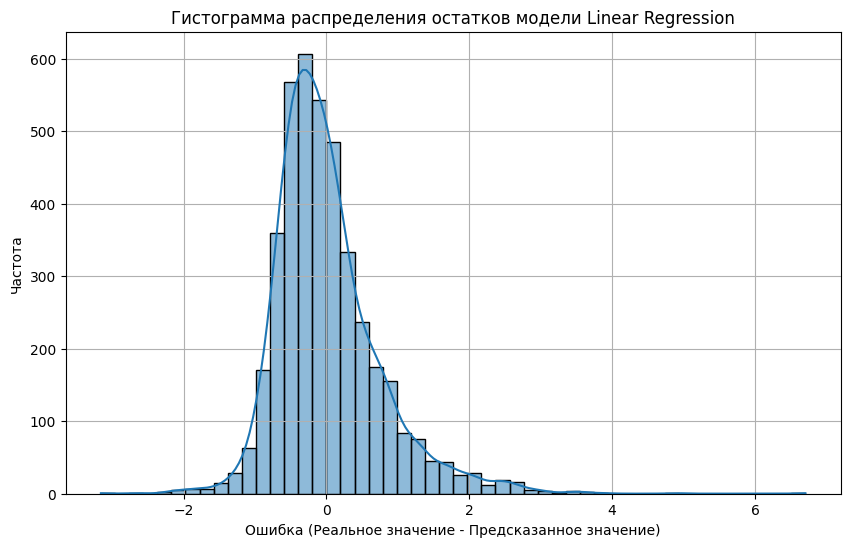

Тест Колмогорова-Смирнова на нормальность остатков: p-value = 7.227419632744262e-33
Вывод: Распределение остатков статистически отличается от нормального (отвергаем H0).

--- 7.2 Анализ на гетероскедастичность ---


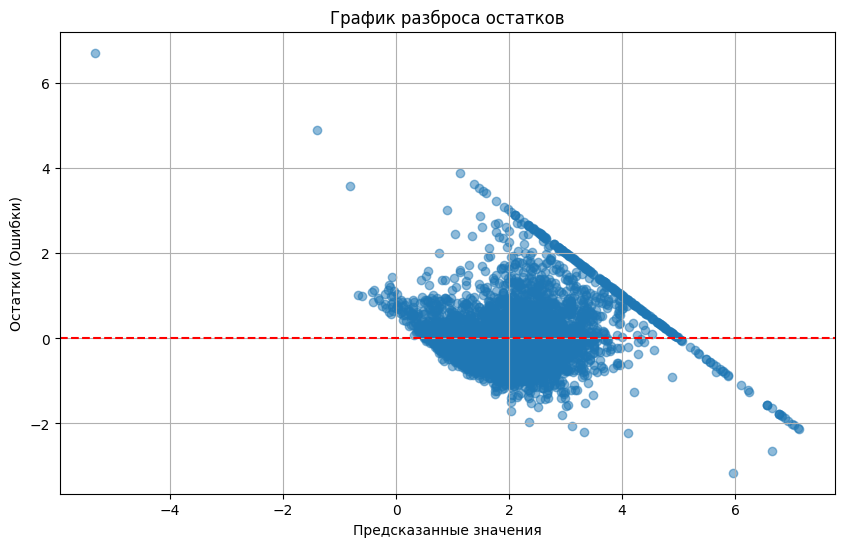


Тест Уайта на гетероскедастичность:
{'LM Statistic': np.float64(3774.4518498124557), 'LM-Test p-value': np.float64(0.0), 'F-Statistic': np.float64(110.89956937839035), 'F-Test p-value': np.float64(0.0)}
Вывод: Гипотеза о гомоскедастичности отвергается (p < 0.05). Присутствует гетероскедастичность.


In [11]:
# Анализ остатков лучшей модели (Linear Regression)
predictions_best = lr_model.predict(X_test_scaled)


residuals = y_test - predictions_best

print("--- 7.1 Анализ нормальности распределения остатков ---")

# Строим гистограмму для визуальной оценки
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, bins=50)
plt.title('Гистограмма распределения остатков модели Linear Regression')
plt.xlabel('Ошибка (Реальное значение - Предсказанное значение)')
plt.ylabel('Частота')
plt.grid(True)
plt.show()

# Тест Колмогорова-Смирнова на нормальность распределения остатков
residuals_scaled = (residuals - np.mean(residuals)) / np.std(residuals)

# Нулевая гипотеза (H0): остатки распределены нормально.
stat, p_value_ks = kstest(residuals_scaled, 'norm')

print(f'Тест Колмогорова-Смирнова на нормальность остатков: p-value = {p_value_ks}')
if p_value_ks > 0.05:
    print("Вывод: Распределение остатков не отличается от нормального (не отвергаем H0).")
else:
    print("Вывод: Распределение остатков статистически отличается от нормального (отвергаем H0).")



print("\n--- 7.2 Анализ на гетероскедастичность ---")

# Визуальный анализ остатков
plt.figure(figsize=(10, 6))
# По оси X - предсказанные значения, по оси Y - остатки (ошибки)
plt.scatter(predictions_best, residuals, alpha=0.5)
# Добавляем горизонтальную линию на уровне нуля, чтобы видеть отклонения
plt.axhline(y=0, color='r', linestyle='--')
plt.title('График разброса остатков')
plt.xlabel('Предсказанные значения')
plt.ylabel('Остатки (Ошибки)')
plt.grid(True)
plt.show()
# Формальный тест Уайта на гетероскедастичность
# Нулевая гипотеза (H0): гомоскедастичность (разброс ошибок постоянный - это хорошо).
white_test_results = het_white(model_sm.resid, model_sm.model.exog)
labels = ['LM Statistic', 'LM-Test p-value', 'F-Statistic', 'F-Test p-value']

print("\nТест Уайта на гетероскедастичность:")
print(dict(zip(labels, white_test_results)))

# Интерпретация результата по p-value F-теста
# Нас интересует p-value для LM-теста (второе значение в результате)
if white_test_results[1] > 0.05:
    print("Вывод: Статистических оснований отвергать гипотезу о гомоскедастичности нет (p > 0.05).")
else:
    print("Вывод: Гипотеза о гомоскедастичности отвергается (p < 0.05). Присутствует гетероскедастичность.")

Анализ остатков модели показал, что ключевые предположения линейной регрессии нарушены. Остатки не распределены нормально (тест Колмогорова-Смирнова, p < 0.05) и присутствует явная гетероскедастичность (тест Уайта, p < 0.05).
Это означает, что точность модели непостоянна: она хорошо предсказывает цены на дешевые дома, но ее ошибка значительно возрастает при прогнозировании цен на дорогие дома.